In [1]:
import os
# MUST be set BEFORE torch (or fastai) is ever imported.
# Without this, any MPS-unsupported op (e.g. adaptive_avg_pool2d, certain loss ops)
# raises RuntimeError instead of silently falling back to CPU.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

!pip install -Uqq fastbook


In [2]:
#hide
from fastbook import *

##  Deep-learning
It is a subset of machine learning that uses neural networks with three or more layers,  to learn directly from data, instead of being explicitly told what to look for, these networks automatically  discover patterns and features in large datasets, making them particularly effective for tasks like image recognition, natural language processing,r
speech recognition.

# Model Training, Validation & Deployment Pipeline

---

## Phase 1 — Data Preparation

| Step | Action |
|------|--------|
| i | **Acquire the Dataset** — Source raw data relevant to the problem. |
| ii | **Label the Data** — Assign ground-truth labels to each sample. |
| iii | **Categorize the Data** — Organize data into meaningful classes or groups. |
| iv | **Split the Data** — Partition into a **Training Set** and a held-out **Validation Set**. |
| v | **Train** — Fit the model on the training data and evaluate training-time performance. |
| vi | **Validate** — Assess generalization by evaluating on the unseen validation set. |

---

## Phase 2 — Training Loop

### 1. Initialize Model Parameters
Set all weights and biases to their starting values (e.g., random initialization or a pretrained checkpoint).

---

### 2. Define the Loss Function
The loss function quantifies *how wrong* the model's predictions are relative to the ground truth.

| Problem Type | Common Loss Function |
|---|---|
| Classification | Cross-Entropy Loss |
| Regression | Mean Squared Error (MSE) |

---

### 3. Choose an Optimizer
The optimizer adjusts model parameters to *minimize* the loss.

| Optimizer | Characteristic |
|---|---|
| **SGD** | Simple, reliable, requires careful LR tuning |
| **Adam** | Adaptive learning rates, robust default choice |

---

### 4. Set the Learning Rate
The learning rate controls the **step size** taken at each update iteration toward the loss minimum.

> A rate too high → overshooting; too low → painfully slow convergence.

---

### 5. Iterate Over Epochs
One **epoch** = one complete pass through the entire training dataset.  
Training runs for multiple epochs until the model converges.

---

### 6. Mini-Batch Processing
Rather than processing all data at once, the dataset is divided into **mini-batches** — small subsets processed sequentially per epoch. This balances computational efficiency with stable gradient estimates.

---

### 7. Forward Pass
For each mini-batch, the model computes predictions using its **current parameters**.

```
Input → Model → Predictions (ŷ)
```

---

### 8. Compute Loss
The loss function measures the **discrepancy** between predictions `ŷ` and actual labels `y`.

```
Loss = L(ŷ, y)
```

---

### 9. Backward Pass (Backpropagation)
The computed loss is propagated **backward** through the network.  
Gradients are calculated — quantifying *how much each weight contributed to the error*.

```
∂Loss/∂w  →  for every weight w in the network
```

---

### 10. Update Weights
The optimizer applies the gradients to update all model parameters, moving them in the direction that **reduces the loss**.

```
w  ←  w − η · ∂Loss/∂w
```
where `η` is the learning rate.

---

### 11. Periodic Validation
After each epoch (or a fixed number of iterations), evaluate on the **validation set** to:

- Monitor generalization to unseen data
- Detect **overfitting** — when training loss falls but validation loss rises

> **Overfitting signal:** High training accuracy + Low validation accuracy = the model has memorized, not learned.

---

## Training Loop — Summary Flow

```
Initialize Parameters
        │
        ▼
┌─── For each Epoch ───────────────────────────────────┐
│                                                       │
│   For each Mini-Batch:                                │
│       1. Forward Pass  →  Generate Predictions        │
│       2. Compute Loss  →  Measure Error               │
│       3. Backward Pass →  Calculate Gradients         │
│       4. Update Weights → Minimize Loss               │
│                                                       │
│   End of Epoch → Evaluate on Validation Set           │
└───────────────────────────────────────────────────────┘
        │
        ▼
  Converged? → Proceed to Deployment
```

Topics to cover in the next section:
Deep Dive into Deep Learning
Architecture of the computer vision model
NLP Model
a tabular Model
How to Create a architecture that matches the needs of your particular domain.
How to get the best possible results from the training process.
How do you make things faster?
How to  you have to change as your database changes?


### Need to learn
1. Different types of the layers.
2. Regularization techniques.
3. Optimization techniques/ Optimizers
4. How to put layers into a model architecture.
5. Labelling techniques

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)


Need to extract the breed of each pet 
in this case need to understand how  the data is laid out.
Such details of data layout are a vital piece of the deep learning puzzle. Data is usually provided in one of these two ways
Individual files representing items of data, such as text documents or images, possibly organized into folders or with filenames representing information about those items
A table of data, such as in CSV format, where each row is an item which may include filenames providing a connection between the data in the table and data in other formats, such as text documents and images

In [4]:
# Lets see what is in   dataset
Path.BASE_PATH=path

In [5]:
path.ls()

[Path('images'), Path('annotations')]

https://www.google.com/url?q=https%3A%2F%2Fwww.robots.ox.ac.uk%2F%7Evgg%2Fdata%2Fpets%2Fhttps://www.google.com/url?q=https%3A%2F%2Fwww.robots.ox.ac.uk%2F%7Evgg%2Fdata%2Fpets%2F

annotation directory tells us it  contains   the information about where the pets are   rather than what they   are 

As we are doing classification  we are care about the what the pets are instead of where they are.
so ignore  the annotation directory and focus on the images directory which contains the images of the pets and the labels are in the file name itself.

In [6]:
(path/"images").ls()
print(path)

/Users/manojkumar/.fastai/data/oxford-iiit-pet


Obeservation 
7393--> number of files in the images directory
pug_52.jpg
asset_hound_112.jpg
somename_number.extension 
somename_otherName_number.extension 


In [7]:
#Lets Check Further 
fname = (path/"images").ls()[0]
fname,

(Path('images/Egyptian_Mau_167.jpg'),)

In [8]:
#use the regex against the fname
re.findall(r'^(.*)_\d+.jpg$', fname.name)

['Egyptian_Mau']

In [9]:
#re works for one example now lets use it for all  data set
pets=DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=using_attr(RegexLabeller(r'^(.*)_\d+.jpg$'), 'name'),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)
dls=pets.dataloaders(path/"images")


item_tfms=Resize(460),
batch_tfms=aug_transforms(size=224, min_scale=0.75),
here lines implement a fastai data augmentation strategy which we call presizing. Presizing is a particular way to do image augmentation that is designed to minimize data destruction while maintaining good performance. The idea is to first resize the image to a larger size (in this case, 460 pixels) and then apply random augmentations that may include cropping, flipping, rotating, etc., while ensuring that the final output size is 224 pixels. This approach allows the model to learn from a variety of augmented images while preserving important features and details in the original image.

Copied 'Egyptian_Mau_167.jpg' to '/Users/manojkumar/workspace/project26/notebooks/images/Egyptian_Mau_167.jpg'
You can now find the image in: /Users/manojkumar/workspace/project26/notebooks/images


[Path('/Users/manojkumar/workspace/project26/notebooks/images/Egyptian_Mau_167.jpg')]

Displaying the copied image:


<Axes: >

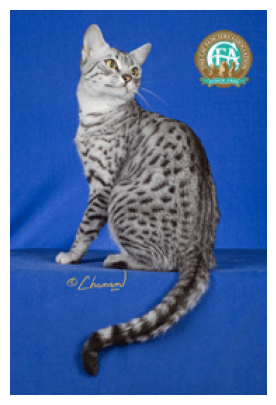

In [10]:
#helper function to copy  the image 
import shutil
from pathlib import Path

# Get the path to the first image in the fastai pets dataset
source_image_path = (path/"images").ls()[0]

# Define the target directory in the CWD
target_dir = Path.cwd() / 'images'

# Create the target directory if it doesn't exist
target_dir.mkdir(exist_ok=True)

# Define the destination path for the copied image
destination_image_path = target_dir / source_image_path.name

# Copy the image
shutil.copy(source_image_path, destination_image_path)

print(f"Copied '{source_image_path.name}' to '{destination_image_path}'")
print(f"You can now find the image in: {target_dir}")

# Verify the image is in the CWD's 'images' folder
display(target_dir.ls())
#load and display the Image
print("Displaying the copied image:")
img=PILImage.create(destination_image_path)
img.show()

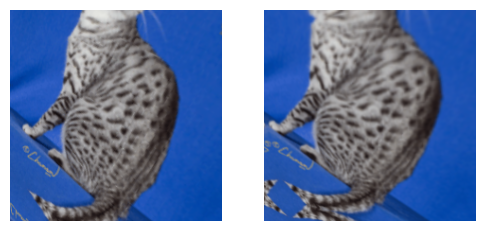

In [11]:
#hide_input
#id interpolations
#caption A comparison of fastai's data augmentation strategy (left) and the traditional approach (right).

# DataBlock defines the blueprInt of the dataset pipeline:
#   ImageBlock()    → each input item is an image
#   CategoryBlock() → each label is a category (class name)
#   get_y=parent_label → label is derived from the parent folder name
#   item_tfms=Resize(224) → resize every image to 224x224 BEFORE batching
#                           (using 224 here avoids the >2x downscale that breaks affine_coord)
dblock1 = DataBlock(blocks=(ImageBlock(), CategoryBlock()),
                   get_y=parent_label,
                   item_tfms=Resize(224))

# Uses the image copied in the previous cell from the pets dataset images/ folder
img_path = (Path.cwd()/'images').ls()[0]      # pick the first image from local images/ folder

# dataloaders() creates train/valid DataLoaders from the list of 100 copies of the same image
# bs=8 → process 8 images per batch
dls1 = dblock1.dataloaders([img_path]*100, bs=8)

# Override the training index generator so the SAME image is always returned
# Inf.ones → an infinite iterator of 1s, so index 1 (same image) is always picked
dls1.train.get_idxs = lambda: Inf.ones

# one_batch() returns one mini-batch: x=images tensor (B,C,H,W), y=labels tensor
x, y = dls1.valid.one_batch()

# Create a 1-row, 2-column subplot to show both images side-by-side
_,axs = subplots(1, 2)

# ── TRADITIONAL APPROACH (right subplot) ─────────────────────────────────────
# Clone x so we don't modify the original batch
x1 = TensorImage(x.clone())

# affine_coord(sz=224): applies an affine grid transformation and resizes to 224x224.
# With input already at 224, this is effectively a no-op resize (identity transform),
# but it initialises the coordinate grid needed by downstream transforms.
x1 = x1.affine_coord(sz=224)

# rotate: randomly rotates the image up to 30 degrees. p=1. means always apply.
x1 = x1.rotate(draw=30, p=1.)

# zoom: randomly zooms in by factor 1.2 (i.e. 20% zoom). p=1. means always apply.
x1 = x1.zoom(draw=1.2, p=1.)

# warp: applies a perspective warp — shifts the grid in x and y direction.
# draw_x=-0.2, draw_y=0.2 controls the distortion amount. p=1. always applies.
# PROBLEM: each transform above applies a SEPARATE grid_sample() call,
# meaning the image is interpolated 4 times → quality degrades each time.
x1 = x1.warp(draw_x=-0.2, draw_y=0.2, p=1.)

# ── FASTAI PRESIZING PIPELINE (left subplot) ──────────────────────────────────
# setup_aug_tfms() creates a list of GPU-optimised augmentation transforms.
# Each transform here accepts a size= argument so they know the OUTPUT size upfront.
tfms = setup_aug_tfms([
    Rotate(draw=30, p=1, size=224),               # rotate up to 30 degrees, output 224x224
    Zoom(draw=1.2, p=1., size=224),               # zoom by 1.2x, output 224x224
    Warp(draw_x=-0.2, draw_y=0.2, p=1., size=224) # perspective warp, output 224x224
])

# Pipeline(tfms) chains all transforms together.
# KEY ADVANTAGE: fastai FUSES all affine transforms into a SINGLE grid_sample() call
# → the image is only interpolated ONCE, preserving more quality than the traditional way.
x = Pipeline(tfms)(x)

# Show fastai pipeline result on the LEFT (x[0] = first image in the batch)
TensorImage(x[0]).show(ctx=axs[0])

# Show traditional sequential result on the RIGHT (x1[0] = first image in the batch)
TensorImage(x1[0]).show(ctx=axs[1]);

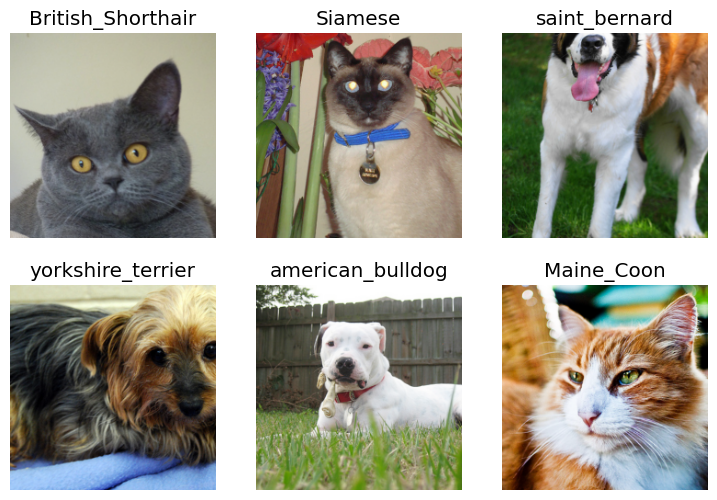

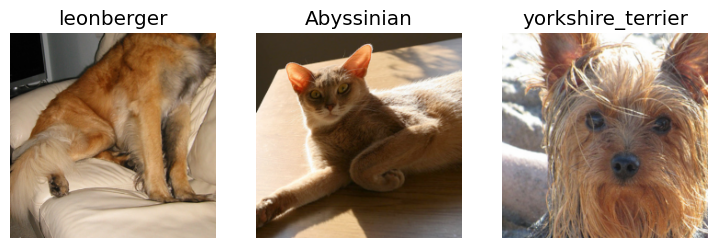

In [12]:
#before training always check the data
dls.show_batch(max_n=6)
dls.show_batch(nrows=1, ncols=3)


In [13]:
# Before proceding further  use the summary method to make sure everything is in place
#hide_output
pets1 = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(224))  # Required: all images must be same size before batching
pets1.summary(path/"images")

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      /Users/manojkumar/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=375x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      /Users/manojkumar/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying partial gives
      saint_bernard
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(30)

Final sample: (PILImage mode=RGB size=375x500, TensorCategory(30))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'a

Here Notice one thing How we went from a file name to sample(the tuple(image, category)), this is the power of the data block API, it allows us to easily define how to get the labels from the file names using the `get_y` parameter and the `RegexLabeller` function. This way we can easily extract the breed of each pet from the file name and use it as the label for our classification task.
If we found data looks to be write then plan to train  a  simple model
For the reason we will use the sample model to  test 
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

In [ ]:
import torch
import torch.nn.functional as F

# ── MPS SETUP ────────────────────────────────────────────────────────────────
# Apple Silicon MPS supports most ops but has a known bug in adaptive_avg_pool2d:
# input sizes must be divisible by output sizes, otherwise it raises RuntimeError.
# PYTORCH_ENABLE_MPS_FALLBACK only covers ops that are UNIMPLEMENTED on MPS;
# it does NOT cover ops that are implemented but buggy (like this pool case).
# Fix: monkey-patch F.adaptive_avg_pool2d to silently fall back to CPU for that
# specific op while keeping everything else on MPS.

_orig_pool = F.adaptive_avg_pool2d

def _mps_safe_pool(input, output_size):
    try:
        return _orig_pool(input, output_size)
    except RuntimeError:
        # Non-divisible sizes: run on CPU, return result on original device
        return _orig_pool(input.cpu(), output_size).to(input.device)

F.adaptive_avg_pool2d = _mps_safe_pool
torch.nn.functional.adaptive_avg_pool2d = _mps_safe_pool   # alias used by some versions

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Build dataloaders with device= directly (NOT via defaults.device beforehand,
# which would push DataBlock validation ops onto MPS and crash).
dls = pets.dataloaders(path/"images", device=device)

# Safe to set global default now — model + optimizer will also land on MPS
defaults.device = device

# vision_learner: binds data + ResNet34 pretrained backbone + loss + optimizer
learn = vision_learner(dls, resnet34, metrics=error_rate)

# fine_tune(2): 2-stage transfer learning
# Stage 1 — freeze backbone, train only the new classification head for 1 epoch
# Stage 2 — unfreeze all layers, train with discriminative LRs for 2 epochs



Using device: mps


epoch,train_loss,valid_loss,error_rate,time
0,1.507401,0.338733,0.111637,01:22


epoch,train_loss,valid_loss,error_rate,time
0,0.515408,0.262224,0.088633,01:47
1,0.311138,0.219988,0.075101,01:47


### Fine tune the model
Fine-tuning is a technique in deep learning where you take a pre-trained model (a model that has already been trained on a large dataset) and adapt it to a new, often smaller, dataset. This is done by continuing the training process on the new dataset, allowing the model to learn the specific features and patterns of the new data while retaining the general knowledge it gained from the original training.

In [18]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.241424,0.268152,0.080514,01:25


epoch,train_loss,valid_loss,error_rate,time
0,0.277597,0.319823,0.090663,01:47
1,0.253545,0.273531,0.080514,01:47
2,0.153061,0.226450,0.064276,01:47


In [17]:
import time

def time_training(device_str, epochs=1):
    """Train for 1 freeze epoch on the given device and return elapsed seconds."""
    dev = torch.device(device_str)

    # Override global defaults so vision_learner places the model on dev
    prev_device = defaults.device
    defaults.device = dev

    try:
        _dls = pets.dataloaders(path/"images", device=dev)
        _learn = vision_learner(_dls, resnet34, metrics=error_rate)
        # Explicit guarantee: move model + optimizer state to dev regardless
        # of any global state left over from previous training runs.
        _learn.model = _learn.model.to(dev)
        _learn.dls.device = dev

        _learn.freeze()
        t0 = time.perf_counter()
        _learn.fit(epochs, lr=1e-3)
        elapsed = time.perf_counter() - t0
    finally:
        defaults.device = prev_device   # always restore to MPS

    return elapsed

print("Timing 1 epoch on CPU ...")
cpu_secs = time_training("cpu")
print(f"  CPU  : {cpu_secs:.1f}s")

if torch.backends.mps.is_available():
    print("Timing 1 epoch on MPS ...")
    mps_secs = time_training("mps")
    print(f"  MPS  : {mps_secs:.1f}s")
    print(f"  Speedup: {cpu_secs/mps_secs:.1f}× faster on MPS")
else:
    print("MPS not available on this machine.")


Timing 1 epoch on CPU ...


epoch,train_loss,valid_loss,error_rate,time
0,0.840556,0.288826,0.095399,04:55


  CPU  : 295.8s
Timing 1 epoch on MPS ...


epoch,train_loss,valid_loss,error_rate,time
0,0.856663,0.292874,0.100135,01:22


  MPS  : 82.5s
  Speedup: 3.6× faster on MPS


## Loss function : 
1. Root mean squared error (RMSE): Basically it is used in regression problem , it measure the average magnitude of the errors, giving higher weight to the larger errors.
2. Means Absolute Error (MAE): MAE calculates the average of the absolute defferences between the predicted values and the actual    values.
Cross Entropy Loss: This is for classification problem, it measures the difference between two probability distributions, the predicted distribution and the true distribution. It is commonly used in multi-class classification problems where the output is a probability distribution over multiple classes.
# Advantages of Cross-Entropy Loss:it works when our dependent variable has more  than  two categories,
It result in faster and more reliable training.

Viewing Activations and Labels

In [19]:
# To get a batch of real data  from our DataLoaders, we can use the one_batch() method. This will return a single batch of data from the DataLoader, which includes both the input images and their corresponding labels. Here's how you can do it:
x,y=dls.one_batch()

In [21]:
y

TensorCategory([ 2, 29, 16,  8,  2, 15, 23, 31, 34, 26, 28, 28,  1, 11, 34, 30,  2, 13, 18,  4, 34, 27,  7,  4, 23,  0, 13,  1, 14, 23, 24,  3, 16, 17, 23, 13, 16, 11,  9,  0,  0, 11, 15, 13, 29, 16,
                34, 21, 34,  8, 14, 24, 23, 33,  1, 20, 15, 22, 35, 29, 14, 32,  1,  4], device='mps:0')

batch size is 64, so we have 64 rows in the tensor, Each row a single integer between 0 and 36,   representing our 37 possible pet breads.
We can get the prediction using learner.get_preds() method,This is activation of the final layer of our neural network.
This  fucntion either takes a data  set index (e.g. 0 for training set, 1 for validation set) or a dataloader (e.g. dls.train or dls.valid) as an argument and returns predictions and targets by defaults but since we already have the targets in the variable y,  we can effectively ignore them by assigning to the special variable _:

In [28]:
preds,_ = learn.get_preds(dl=[(x,y)])
preds[0]

tensor([4.5834e-06, 8.9446e-06, 9.6423e-01, 4.3874e-05, 1.6336e-05, 2.3397e-06, 2.3903e-05, 5.0996e-04, 3.4064e-02, 1.5930e-07, 4.5580e-04, 1.7293e-06, 3.8124e-06, 1.8448e-06, 2.4733e-06, 1.3547e-06,
        8.5730e-06, 2.3448e-06, 1.9759e-05, 1.3525e-07, 2.7981e-06, 6.0878e-06, 4.7172e-05, 2.3680e-04, 2.8601e-06, 4.7058e-05, 3.9184e-07, 3.8353e-06, 1.2386e-04, 2.7889e-05, 1.3324e-05, 5.7652e-06,
        2.4181e-06, 1.3012e-05, 4.5283e-07, 3.1715e-06, 6.4163e-05])

In [ ]:
#len(preds[0])==> The number of elements in first prediction vector 
#so it tell us  how many  distinct categories the model is predicting for, which is 37 in our case (37 pet breeds). 
#pred[0].sum () gives us the sum of all the values in the first prediction vector, which can be useful for understanding the distribution of the predicted probabilities across the different classes.
len(preds[0]), preds[0].sum()

(37, tensor(1.))

#Softmax The Activation function
The softmax function is a mathematical function that converts a vector of real numbers into a probability distribution
It is commonly used in the output layer of a neural network for multi-class classification problems, where the goal is to assign probabilities to each class. The softmax function takes a vector of raw scores (logits) and transforms them into probabilities that sum to 1, allowing us to interpret the output as a probability distribution over the classes.

Softmax is similar to sigmoid function but it is used for multi-class classification problems, while sigmoid is used for binary classification problems. Softmax outputs a probability distribution over multiple classes, while sigmoid outputs a probability for a single class.
Sigmoid fucntion looks like 
plot_function(torch.sigmoid, min=-4,max=4)

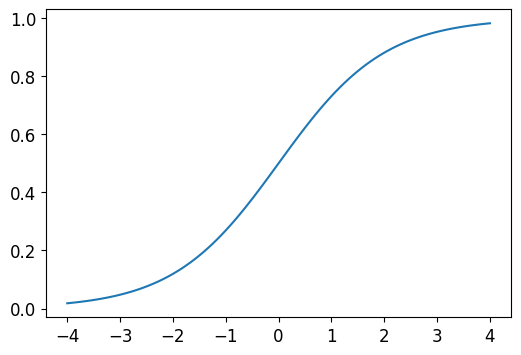

In [31]:
plot_function(torch.sigmoid, min=-4,max=4)

In [32]:
torch.random.manual_seed(42);

In [33]:
acts = torch.randn((6,2))*2
acts

tensor([[ 0.6734,  0.2576],
        [ 0.4689,  0.4607],
        [-2.2457, -0.3727],
        [ 4.4164, -1.2760],
        [ 0.9233,  0.5347],
        [ 1.0698,  1.6187]])

In [34]:
acts.sigmoid()

tensor([[0.6623, 0.5641],
        [0.6151, 0.6132],
        [0.0957, 0.4079],
        [0.9881, 0.2182],
        [0.7157, 0.6306],
        [0.7446, 0.8346]])

In [35]:
(acts[:,0]-acts[:,1]).sigmoid()

tensor([0.6025, 0.5021, 0.1332, 0.9966, 0.5959, 0.3661])

In [36]:
def softmax(x): return exp(x) / exp(x).sum(dim=1, keepdim=True)

In [37]:
sm_acts = torch.softmax(acts, dim=1)
sm_acts

tensor([[0.6025, 0.3975],
        [0.5021, 0.4979],
        [0.1332, 0.8668],
        [0.9966, 0.0034],
        [0.5959, 0.4041],
        [0.3661, 0.6339]])

In the binary case, we used torch.where to select between inputs and 1-inputs. When we treat a binary classification as a general classification problem with two categories, it actually becomes even easier, because (as we saw in the previous section) we now have two columns, containing the equivalent of inputs and 1-inputs. Since there is only one correct label per example, all we need to do is select the appropriate column (as opposed to multiplying multiple probabilities). Let's try to implement this in PyTorch. For our synthetic 3s and 7s example, let's say these are our labels:

In [38]:
targ = tensor([0,1,0,1,1,0])

In [39]:
#and these are the softmax activations:
sm_acts

tensor([[0.6025, 0.3975],
        [0.5021, 0.4979],
        [0.1332, 0.8668],
        [0.9966, 0.0034],
        [0.5959, 0.4041],
        [0.3661, 0.6339]])

Then for each item of targ we can use that to select the appropriate column of sm_acts using tensor indexing, like so:

In [40]:
idx = range(6)
sm_acts[idx, targ]

tensor([0.6025, 0.4979, 0.1332, 0.0034, 0.4041, 0.3661])

To see exactly what's happening here, let's put all the columns together in a table. Here, the first two columns are our activations, then we have the targets and the row index. We explain the last column, result below:

In [42]:
#hide_input
from IPython.display import HTML
df['loss'] = -torch.log(tensor(df['result']))
t = df.style.hide(axis='index') # Changed hide_index() to hide(axis='index')
#To have html code compatible with our script
html = t._repr_html_().split('</style>')[1]
html = re.sub(r'<table id="([^\"]+)"\s*>', r'<table >', html)
display(HTML(html))

/Users/manojkumar/venvs/jupyter/lib/python3.12/site-packages/fastai/torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  else as_tensor(x.values, **kwargs) if isinstance(x, (pd.Series, pd.DataFrame))


3,7,targ,idx,result,loss
0.602469,0.397531,0,0,0.602469,0.506720
0.502065,0.497935,1,1,0.497935,0.697285
0.133188,0.866811,0,2,0.133188,2.015990
0.996640,0.003360,1,3,0.003360,5.695763
0.595949,0.404051,1,4,0.404051,0.906213
0.366118,0.633882,0,5,0.366118,1.004798


When we first take the softmax, and then the log likelihood of that, that combination is called cross-entropy loss. In PyTorch, this is available as nn.CrossEntropyLoss (which, in practice, actually does log_softmax and then nll_loss):

In [43]:
loss_func = nn.CrossEntropyLoss()

In [44]:
loss_func(acts, targ) #This is a class instaintiating gives us the object which behaves as a function but also has some internal state (e.g. for reduction method, label smoothing, etc.

tensor(1.8045)

All PyTorch loss functions are provided in two forms, the class just shown above, and also a plain functional form, available in the F namespace:

In [45]:
F.cross_entropy(acts, targ)

tensor(1.8045)

By default PyTorch loss functions take the mean of the loss of all items. You can use reduction='none' to disable that:

In [46]:
nn.CrossEntropyLoss(reduction='none')(acts, targ)

tensor([0.5067, 0.6973, 2.0160, 5.6958, 0.9062, 1.0048])

s: An interesting feature about cross-entropy loss appears when we consider its gradient. The gradient of cross_entropy(a,b) is just softmax(a)-b. Since softmax(a) is just the final activation of the model, that means that the gradient is proportional to the difference between the prediction and the target. This is the same as mean squared error in regression (assuming there's no final activation function such as that added by y_range), since the gradient of (a-b)**2 is 2*(a-b). Because the gradient is linear, that means we won't see sudden jumps or exponential increases in gradients, which should lead to smoother training of models.
We have now seen all the pieces hidden behind our loss function. But while this puts a number on how well (or badly) our model is doing, it does nothing to help us know if it's actually any good. Let's now see some ways to interpret our model's predictions.

## Model Interpretation

It's very hard to interpret loss functions directly, because they are designed to be things computers can differentiate and optimize, not things that people can understand. That's why we have metrics. These are not used in the optimization process, but just to help us poor humans understand what's going on. In this case, our accuracy is looking pretty good already! So where are we making mistakes?

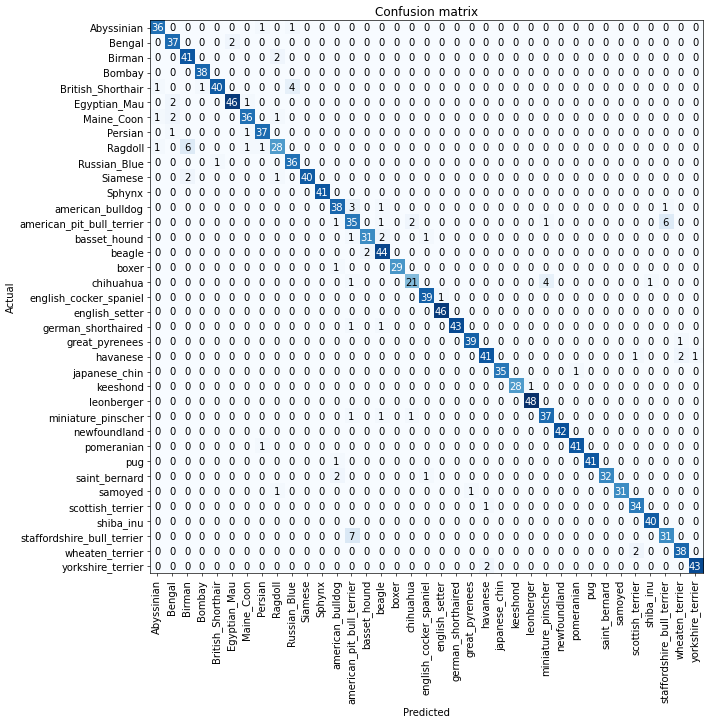

In [47]:
#width 600
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

in this case, a confusion matrix is very hard to read. We have 37 different breeds of pet, which means we have 37×37 entries in this giant matrix! Instead, we can use the most_confused method, which just shows us the cells of the confusion matrix with the most incorrect predictions (here, with at least 5 or more):

In [48]:
interp.most_confused(min_val=5)

[('staffordshire_bull_terrier', 'american_pit_bull_terrier', np.int64(7)),
 ('Ragdoll', 'Birman', np.int64(6)),
 ('american_pit_bull_terrier', 'staffordshire_bull_terrier', np.int64(6))]

## Improving Our Model

We will now look at a range of techniques to improve the training of our model and make it better. While doing so, we will explain a little bit more about transfer learning and how to fine-tune our pretrained model as best as possible, without breaking the pretrained weights.

The first thing we need to set when training a model is the learning rate. We saw in the previous chapter that it needs to be just right to train as efficiently as possible, so how do we pick a good one? fastai provides a tool for this.

One of the most important things we can do when training a model is to make sure that we have the right learning rate. If our learning rate is too low, it can take many, many epochs to train our model. Not only does this waste time, but it also means that we may have problems with overfitting, because every time we do a complete pass through the data, we give our model a chance to memorize it.

So let's just make our learning rate really high, right? Sure, let's try that and see what happens:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1, base_lr=0.1)

epoch,train_loss,valid_loss,error_rate,time
0,2.589709,3.204123,0.378214,01:22


epoch,train_loss,valid_loss,error_rate,time
0,3.355729,1.793808,0.506089,01:48


#### Learning Rate Finder
That doesn't look good. Here's what happened. The optimizer stepped in the correct direction, but it stepped so far that it totally overshot the minimum loss. Repeating that multiple times makes it get further and further away, not closer and closer!

What do we do to find the perfect learning rate—not too high, and not too low? In 2015 the researcher Leslie Smith came up with a brilliant idea, called the learning rate finder. His idea was to start with a very, very small learning rate, something so small that we would never expect it to be too big to handle. We use that for one mini-batch, find what the losses are afterwards, and then increase the learning rate by some percentage (e.g., doubling it each time). Then we do another mini-batch, track the loss, and double the learning rate again. We keep doing this until the loss gets worse, instead of better. This is the point where we know we have gone too far. We then select a learning rate a bit lower than this point. Our advice is to pick either:

One order of magnitude less than where the minimum loss was achieved (i.e., the minimum divided by 10)
The last point where the loss was clearly decreasing

<div></div>

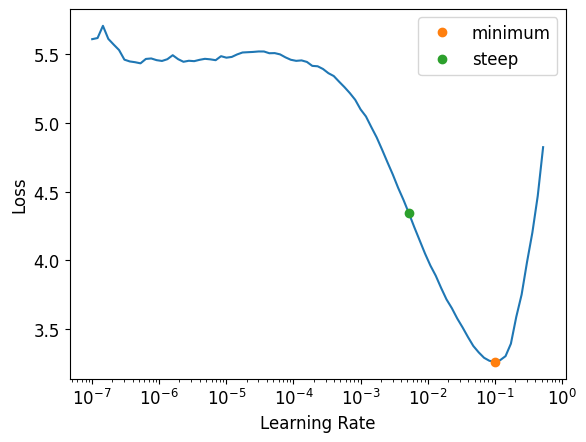

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

We can see on this plot that in the range 1e-6 to 1e-3, nothing really happens and the model doesn't train. Then the loss starts to decrease until it reaches a minimum, and then increases again. We don't want a learning rate greater than 1e-1 as it will give a training that diverges like the one before (you can try for yourself), but 1e-1 is already too high: at this stage we've left the period where the loss was decreasing steadily.

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2, base_lr=3e-3)


epoch,train_loss,valid_loss,error_rate,time
0,1.323314,0.339976,0.115020,01:23


epoch,train_loss,valid_loss,error_rate,time
0,0.545218,0.395295,0.117727,01:50
1,0.322231,0.237636,0.073072,01:49


<div></div>

SuggestedLRs(minimum=1.2022644114040304e-06, steep=3.311311274956097e-06)

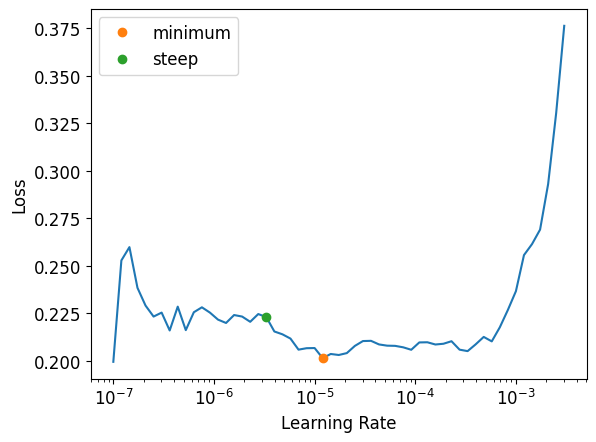

In [55]:
learn.lr_find(suggest_funcs=(minimum, steep))

When we create a model from a pretrained network fastai automatically freezes all of the pretrained layers for us. When we call the `fine_tune` method fastai does two things:

- Trains the randomly added layers for one epoch, with all other layers frozen
- Unfreezes all of the layers, and trains them all for the number of epochs requested

Although this is a reasonable default approach, it is likely that for your particular dataset you may get better results by doing things slightly differently. The `fine_tune` method has a number of parameters you can use to change its behavior, but it might be easiest for you to just call the underlying methods directly if you want to get some custom behavior. Remember that you can see the source code for the method by using the following syntax:

    learn.fine_tune??

So let's try doing this manually ourselves. First of all we will train the randomly added layers for three epochs, using `fit_one_cycle`. As mentioned in <<chapter_intro>>, `fit_one_cycle` is the suggested way to train models without using `fine_tune`. We'll see why later in the book; in short, what `fit_one_cycle` does is to start training at a low learning rate, gradually increase it for the first section of training, and then gradually decrease it again for the last section of training.

In [56]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.194026,0.358205,0.114344,01:23
1,0.528155,0.240368,0.079161,01:22
2,0.337716,0.225729,0.085927,01:22


<div></div>

SuggestedLRs(minimum=6.918309736647643e-07, steep=7.585775847473997e-07)

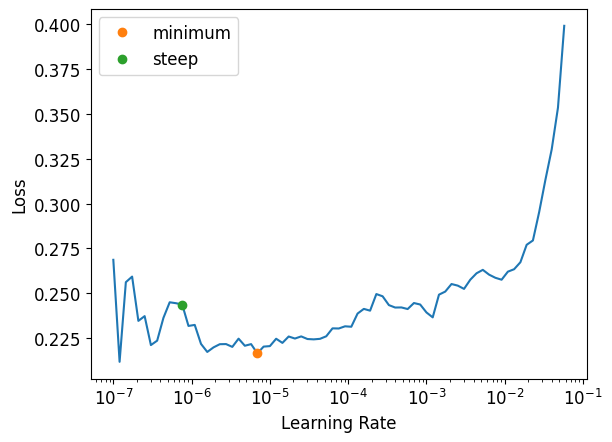

In [57]:
learn.lr_find(suggest_funcs=(minimum, steep))

In [58]:
learn.unfreeze()

<div></div>

SuggestedLRs(valley=0.00015848931798245758)

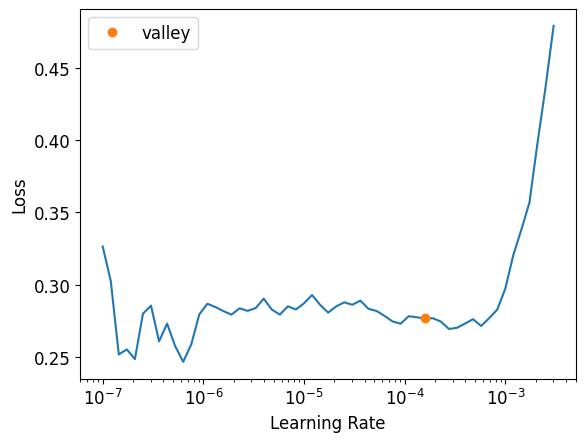

In [59]:
learn.lr_find()

<div></div>

SuggestedLRs(minimum=3.0199516913853586e-06, steep=7.585775847473997e-07)

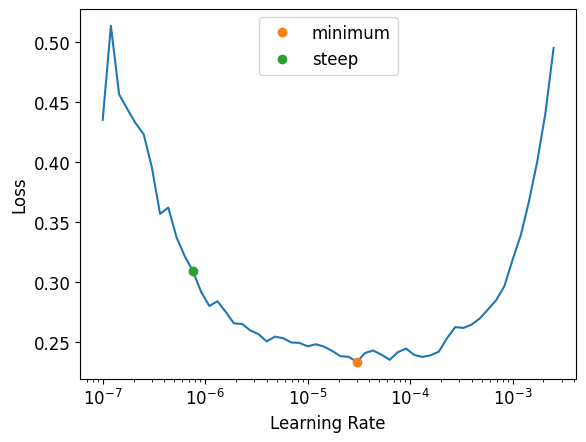

In [60]:
learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn.functional as F
from fastai.vision.all import *

assert torch.backends.mps.is_available(), "MPS not available"

# Make this cell self-contained: create `path`/`pets` if missing
if "path" not in globals():
    path = untar_data(URLs.PETS)

if "pets" not in globals():
    pets = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_items=get_image_files,
        splitter=RandomSplitter(seed=42),
        get_y=using_attr(RegexLabeller(r'^(.*)_\d+.jpg$'), 'name'),
        item_tfms=Resize(460),
        batch_tfms=aug_transforms(size=224, min_scale=0.75),
    )

# MPS workaround for adaptive_avg_pool2d non-divisible sizes
_orig_pool = F.adaptive_avg_pool2d
def _mps_safe_pool(input, output_size):
    try:
        return _orig_pool(input, output_size)
    except RuntimeError:
        return _orig_pool(input.cpu(), output_size).to(input.device)

F.adaptive_avg_pool2d = _mps_safe_pool
torch.nn.functional.adaptive_avg_pool2d = _mps_safe_pool

device = torch.device("mps")
defaults.device = device

# Recreate dataloaders directly from DataBlock
dls = pets.dataloaders(path/"images", device=device)

learn = vision_learner(dls, resnet50, metrics=error_rate)
learn.model.to(device)

print("Learner device:", learn.dls.device)
print("Model device:", next(learn.model.parameters()).device)

# On MPS, use FP32 for stability
learn.fine_tune(6, freeze_epochs=3)

NameError: `pets` is not defined. Run the DataBlock cell that creates `pets` first.

In [ ]:
learn.recorder.plot_loss()

In [ ]:
import torch
from fastai.callback.fp16 import *

# Force MPS execution when available
if not torch.backends.mps.is_available():
    raise RuntimeError("MPS is not available on this machine.")

device = torch.device("mps")
defaults.device = device

# Rebuild dls on MPS so data and model are on the same device
dls = pets.dataloaders(path/"images", device=device)

learn = vision_learner(dls, resnet50, metrics=error_rate)
learn.model.to(device)

print("Learner device:", learn.dls.device)
print("Model device:", next(learn.model.parameters()).device)

# fastai mixed precision is CUDA-focused; keep FP32 on MPS for reliability
# (If you run this on CUDA in future, then call: learn = learn.to_fp16())
learn.fine_tune(6, freeze_epochs=3)